# Estatística descritiva univariada

### Transformação de variáveis quantitativas em qualitativas



Conforme descrito no início deste módulo, as variáveis quantitativas contínuas são aquelas cujos possíveis valores pertencem a um intervalo de números reais. Desta forma, não faz sentido calcular a frequência para cada valor possível, já que eles raramente se repetem. 

Neste contexto, faz sentido agrupar os dados em classes ou faixas. O intervalo a ser definido entre as classes é arbitrário. Porém, se o número de classes for muito pequeno, informações são perdidas; enquanto que, se o número de classes for muito grande, o resumo das informações fica prejudicado. 

O intervalo entre as classes não precisaria ser constante, mas por uma questão de simplicidade e facilidade de interpretação, é costume adotar um intervalo constante.


Para ilustrar, usaremos a seguinte base de dados, com as notas finais de 30 alunos em uma disciplina de estatística de uma universidade.

In [39]:
import pandas as pd

DADOS = "../dados/grades.csv"

df_notas = pd.read_csv(DADOS)

df_notas.head()

,grades
0,4.2
1,3.9
2,5.7
3,6.5
4,4.6


In [40]:
df_notas.tail()

,grades
25,5.0
26,6.6
27,7.1
28,5.3
29,4.7


In [41]:
df_notas.describe()

,grades
count,30.000000
mean,5.686667
std,1.318498
min,3.500000
25%,4.700000
50%,5.500000
75%,6.575000
max,8.800000


In [42]:
#problema com valores continuos

df_notas["grades"].value_counts()

grades
5.0    4
5.5    2
6.0    2
7.2    2
4.7    2
4.2    1
3.9    1
5.7    1
6.5    1
4.6    1
6.3    1
8.0    1
4.4    1
4.5    1
6.4    1
6.8    1
3.5    1
7.4    1
8.8    1
3.8    1
6.6    1
7.1    1
5.3    1
Name: count, dtype: int64

In [43]:
df_notas["grades"].value_counts(bins=10)

(4.56, 5.09]     7
(6.15, 6.68]     4
(6.68, 7.21]     4
(3.494, 4.03]    3
(4.03, 4.56]     3
(5.09, 5.62]     3
(5.62, 6.15]     3
(7.21, 7.74]     1
(7.74, 8.27]     1
(8.27, 8.8]      1
Name: count, dtype: int64

In [44]:
df_notas["grades"].value_counts(bins=10).sort_index()

(3.494, 4.03]    3
(4.03, 4.56]     3
(4.56, 5.09]     7
(5.09, 5.62]     3
(5.62, 6.15]     3
(6.15, 6.68]     4
(6.68, 7.21]     4
(7.21, 7.74]     1
(7.74, 8.27]     1
(8.27, 8.8]      1
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

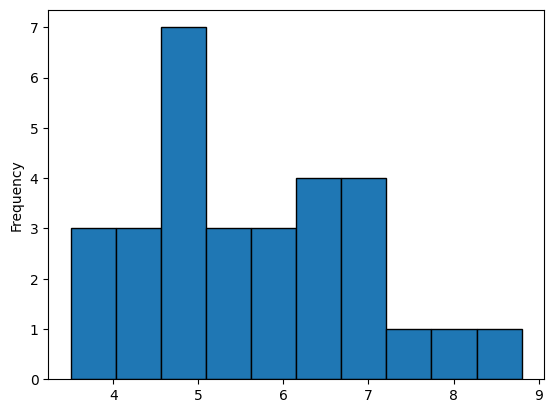

In [45]:
df_notas["grades"].plot.hist(bins=10, edgecolor="black")

Mas qual será a melhor divisão de classes para representar os dados de forma clara e objetiva? A escolha do número de classes e dos intervalos de classe é uma etapa crucial na construção de tabelas de distribuição de frequências e na representação gráfica dos dados.

A regra de Sturges é uma regra empírica utilizada para determinar o número de classes em uma distribuição de frequências. A regra é dada pela fórmula:

$$
k = 1 + \log_{2}(n)
$$

onde *k* é o número de classes e *n* é o número de observações.

In [46]:
df_notas.shape

(30, 1)

In [47]:
import numpy as np

k = 1 + np.log2(df_notas.shape[0])

k

np.float64(5.906890595608519)

In [48]:
k = np.ceil(k)

k

np.float64(6.0)

In [49]:
amplitude = (df_notas["grades"].max() - df_notas["grades"].min()) / k 

amplitude

np.float64(0.8833333333333334)

In [50]:
df_notas["grades"].value_counts(bins=int(k))

(4.383, 5.267]    9
(5.267, 6.15]     6
(6.15, 7.033]     5
(3.494, 4.383]    4
(7.033, 7.917]    4
(7.917, 8.8]      2
Name: count, dtype: int64

In [51]:
df_notas["grades"].value_counts(bins=int(k)).sort_index()

(3.494, 4.383]    4
(4.383, 5.267]    9
(5.267, 6.15]     6
(6.15, 7.033]     5
(7.033, 7.917]    4
(7.917, 8.8]      2
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

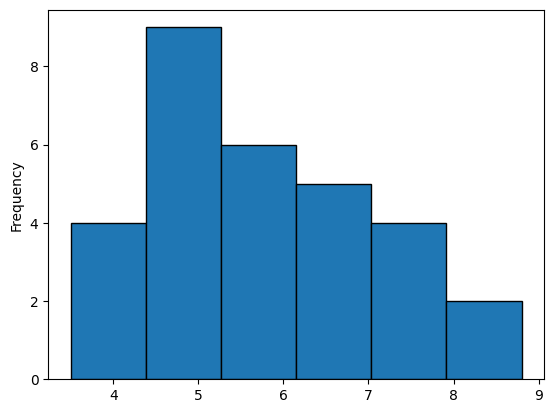

In [52]:
df_notas["grades"].plot.hist(bins=int(k), edgecolor="black")

https://numpy.org/doc/stable/reference/generated/numpy.histogram_bin_edges.html

In [53]:
bins = np.histogram_bin_edges(df_notas["grades"], bins="sturges")

bins

array([3.5       , 4.38333333, 5.26666667, 6.15      , 7.03333333,
       7.91666667, 8.8       ])

In [54]:
tam_intervalo = bins[1:] - bins[:-1]

tam_intervalo

array([0.88333333, 0.88333333, 0.88333333, 0.88333333, 0.88333333,
       0.88333333])

In [55]:
pd.cut(df_notas["grades"], bins=bins) 

0       (3.5, 4.383]
1       (3.5, 4.383]
2      (5.267, 6.15]
3      (6.15, 7.033]
4     (4.383, 5.267]
5      (6.15, 7.033]
6       (7.917, 8.8]
7     (4.383, 5.267]
8     (4.383, 5.267]
9      (5.267, 6.15]
10     (5.267, 6.15]
11    (4.383, 5.267]
12    (4.383, 5.267]
13    (7.033, 7.917]
14     (6.15, 7.033]
15    (7.033, 7.917]
16    (4.383, 5.267]
17     (6.15, 7.033]
18    (4.383, 5.267]
19               NaN
20     (5.267, 6.15]
21    (7.033, 7.917]
22      (7.917, 8.8]
23      (3.5, 4.383]
24     (5.267, 6.15]
25    (4.383, 5.267]
26     (6.15, 7.033]
27    (7.033, 7.917]
28     (5.267, 6.15]
29    (4.383, 5.267]
Name: grades, dtype: category
Categories (6, interval[float64, right]): [(3.5, 4.383] < (4.383, 5.267] < (5.267, 6.15] < (6.15, 7.033] < (7.033, 7.917] < (7.917, 8.8]]

In [56]:
pd.cut(df_notas["grades"], bins=bins).value_counts().sort_index()

grades
(3.5, 4.383]      3
(4.383, 5.267]    9
(5.267, 6.15]     6
(6.15, 7.033]     5
(7.033, 7.917]    4
(7.917, 8.8]      2
Name: count, dtype: int64

In [57]:
pd.cut(df_notas["grades"], bins=bins).value_counts().sort_index().sum()

np.int64(29)

In [58]:
pd.cut(df_notas["grades"], bins=bins, include_lowest=True).value_counts().sort_index()

grades
(3.499, 4.383]    4
(4.383, 5.267]    9
(5.267, 6.15]     6
(6.15, 7.033]     5
(7.033, 7.917]    4
(7.917, 8.8]      2
Name: count, dtype: int64

In [59]:
tamanho_intervalo_int = np.zeros(len(bins))

tamanho_intervalo_int

array([0., 0., 0., 0., 0., 0., 0.])

In [60]:
tamanho_intervalo_int[1:] = np.ceil(tam_intervalo)

tamanho_intervalo_int

array([0., 1., 1., 1., 1., 1., 1.])

In [61]:
np.cumsum(tamanho_intervalo_int)

array([0., 1., 2., 3., 4., 5., 6.])

In [62]:
bins[0]

np.float64(3.5)

In [63]:
bins_arredondados = bins[0] + np.cumsum(tamanho_intervalo_int)

bins_arredondados

array([3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5])

In [64]:
pd.cut(df_notas["grades"], bins=bins_arredondados, include_lowest=True).value_counts().sort_index()

grades
(3.499, 4.5]     6
(4.5, 5.5]      10
(5.5, 6.5]       6
(6.5, 7.5]       6
(7.5, 8.5]       1
(8.5, 9.5]       1
Name: count, dtype: int64

In [65]:
pd.cut(df_notas["grades"], bins=bins_arredondados, include_lowest=True, right=False).value_counts().sort_index()

grades
[3.5, 4.5)    5
[4.5, 5.5)    9
[5.5, 6.5)    7
[6.5, 7.5)    7
[7.5, 8.5)    1
[8.5, 9.5)    1
Name: count, dtype: int64

In [66]:
df_notas_intervalo = pd.cut(df_notas["grades"], bins=bins_arredondados, include_lowest=True, right=False).value_counts().sort_index().to_frame()

In [67]:
df_notas_intervalo

,count
grades,
"[3.5, 4.5)",5
"[4.5, 5.5)",9
"[5.5, 6.5)",7
"[6.5, 7.5)",7
"[7.5, 8.5)",1
"[8.5, 9.5)",1


In [68]:
from auxiliares import tabela_distribuicao_frequencias

tabela_distribuicao_frequencias(df_notas_intervalo, "count", True)

,frequencia,frequencia_relativa,frequencia_acumulada,frequencia_relativa_acumulada
grades,,,,
"[3.5, 4.5)",5,0.166667,5,0.166667
"[4.5, 5.5)",9,0.300000,14,0.466667
"[5.5, 6.5)",7,0.233333,21,0.700000
"[6.5, 7.5)",7,0.233333,28,0.933333
"[7.5, 8.5)",1,0.033333,29,0.966667
"[8.5, 9.5)",1,0.033333,30,1.000000


<Axes: ylabel='Frequency'>

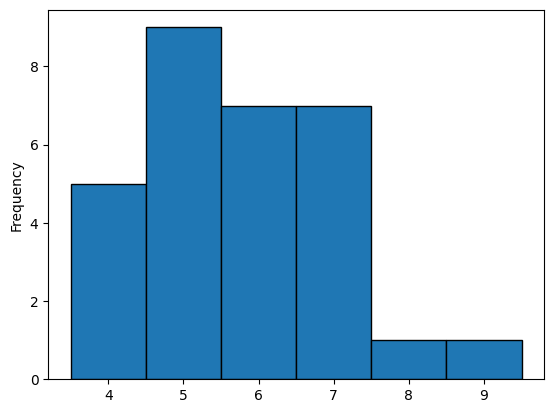

In [69]:
df_notas["grades"].plot.hist(bins=bins_arredondados, edgecolor="black")

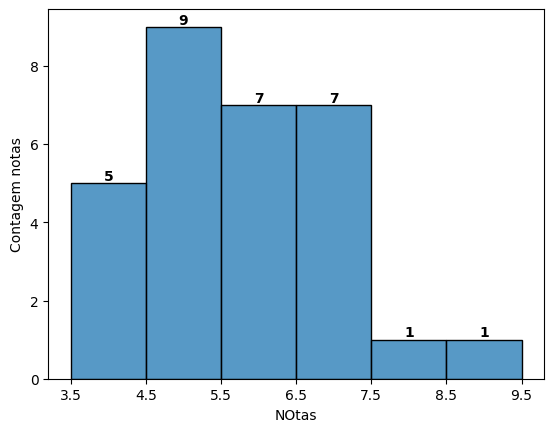

In [79]:
import seaborn as sns 

h = sns.histplot(data=df_notas["grades"], bins=bins_arredondados)

for barra in h.containers:
    h.bar_label(barra, color="black", fontweight="bold")

h.set_ylabel("Contagem notas")
h.set_xlabel("NOtas")

h.set_xticks(bins_arredondados);


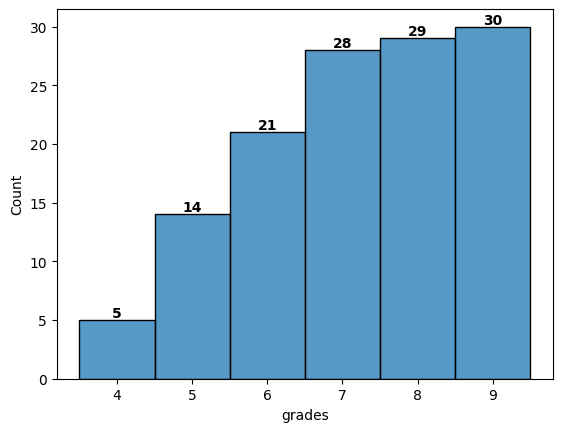

In [81]:
import seaborn as sns 

h = sns.histplot(data=df_notas["grades"], bins=bins_arredondados, cumulative=True)

for barra in h.containers:
    h.bar_label(barra, color="black", fontweight="bold")


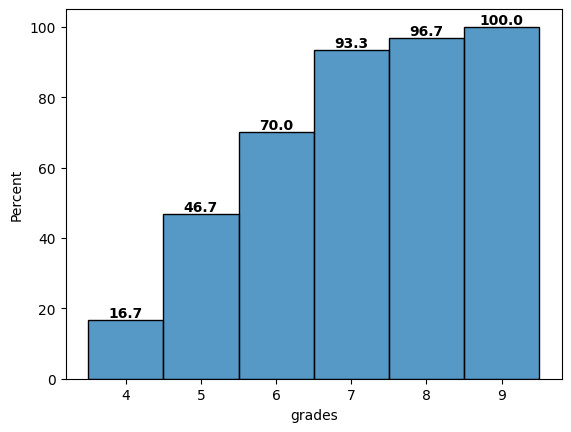

In [83]:
import seaborn as sns 

h = sns.histplot(data=df_notas["grades"], bins=bins_arredondados, cumulative=True, stat="percent")

for barra in h.containers:
    h.bar_label(
        barra, 
        color="black", 
        fontweight="bold",
        labels=[f"{b.get_height():.1f}" for b in barra])


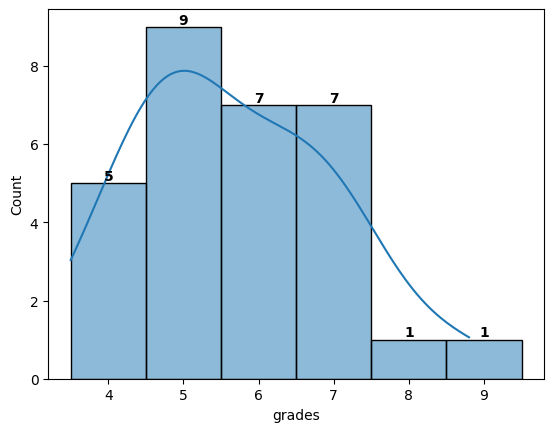

In [85]:
import seaborn as sns 

h = sns.histplot(data=df_notas["grades"], bins=bins_arredondados, kde=True)

for barra in h.containers:
    h.bar_label(
        barra, 
        color="black", 
        fontweight="bold")